In [ ]:
# This is the ML training and testing model for sanity check that the datamart is functionable and usable.

In [15]:
from pyspark.sql import SparkSession
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

spark = SparkSession.builder \
    .appName("ML_Model_Training") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("Spark started")

Spark started


In [16]:
# Loading tables from the gold layer
features = spark.read.parquet("datamart/gold/gold_feature_store").toPandas()
labels = spark.read.parquet("datamart/gold/gold_label_store").toPandas()

print("Feature store shape:", features.shape)
print("Label store shape:", labels.shape)

Feature store shape: (12500, 70)
Label store shape: (12500, 6)


In [17]:
# Merging features and labels 
df = features.merge(labels[["loan_id", "is_default"]], on="loan_id")

print("Merged shape:", df.shape)
print("Default rate:", round(df["is_default"].mean() * 100, 2), "%")
df.head()

Merged shape: (12500, 71)
Default rate: 28.82 %


,Customer_ID,loan_start_date,loan_id,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,fe_16_std,fe_17_mean,fe_17_std,fe_18_mean,fe_18_std,fe_19_mean,fe_19_std,fe_20_mean,fe_20_std,is_default
0,CUS_0x1000,2023-05-01,CUS_0x1000_2023_05_01,18.0,Lawyer,30625.94,2706.161667,6,5,27,...,71.030275,43.400000,64.434463,97.400000,76.474179,80.800000,83.902920,111.200000,80.334924,1
1,CUS_0x100b,2024-03-01,CUS_0x100b_2024_03_01,19.0,Media_Manager,113781.39,9549.782500,1,4,1,...,141.035963,87.142857,131.681976,70.571429,96.259817,233.857143,87.640228,56.571429,124.315267,0
2,CUS_0x1011,2023-11-01,CUS_0x1011_2023_11_01,44.0,Doctor,58918.47,5208.872500,3,3,17,...,106.916523,107.571429,129.026944,64.285714,131.039071,161.857143,117.695127,70.571429,49.399248,0
3,CUS_0x1026,2023-10-01,CUS_0x1026_2023_10_01,52.0,Manager,170614.28,14463.856667,2,6,9,...,126.375668,137.000000,64.982049,132.571429,90.162552,83.571429,91.387193,91.000000,116.445982,0
4,CUS_0x102d,2024-01-01,CUS_0x102d_2024_01_01,31.0,Entrepreneur,89064.52,7256.043333,5,3,1,...,76.366285,127.571429,110.947220,114.714286,58.114009,84.857143,64.746759,69.000000,118.543944,0


In [18]:
# Drop non-numeric/identifier columns
drop_cols = ["loan_id", "Customer_ID", "loan_start_date"]
df_ml = df.drop(columns=drop_cols)

# Convert Occupation to numeric using label encoding
df_ml["Occupation"] = df_ml["Occupation"].astype("category").cat.codes

# Fill nulls with 0
df_ml = df_ml.fillna(0)

# Split features and label
X = df_ml.drop(columns=["is_default"])
y = df_ml["is_default"]

print("Features shape:", X.shape)
print("Label distribution:")
print(y.value_counts())

Features shape: (12500, 67)
Label distribution:
is_default
0    8898
1    3602
Name: count, dtype: int64


In [19]:
# Train and Test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # for reproducibility
    stratify=y          # keeping same default rate in both splits
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (10000, 67)
Test size: (2500, 67)


In [20]:
# Model Training
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained")

Model trained


In [21]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))

Accuracy: 79.4 %
Classification Report:
              precision    recall  f1-score   support

  No Default       0.82      0.90      0.86      1780
     Default       0.69      0.52      0.59       720

    accuracy                           0.79      2500
   macro avg       0.76      0.71      0.73      2500
weighted avg       0.78      0.79      0.78      2500



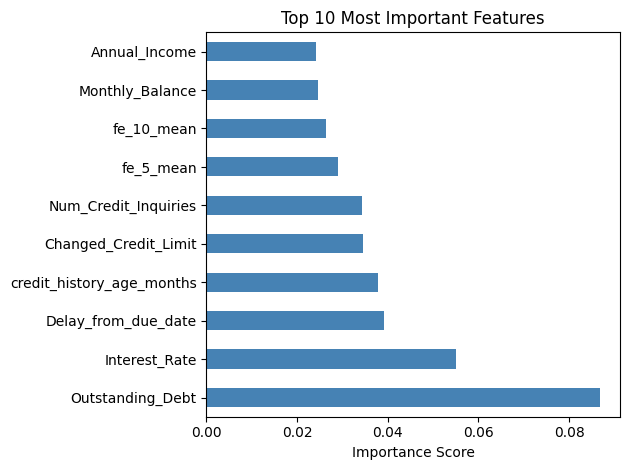

In [22]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_, 
    index=X.columns
).sort_values(ascending=False).head(10)

feature_importance.plot(kind="barh", color="steelblue")
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [23]:
spark.stop()
print("Sanity check complete. Feature store is ML compatible.")

Sanity check complete. Feature store is ML compatible.
